# 05_고도화(1/2) — Optuna 하이퍼파라미터 탐색 (목적함수 = Holdout-Valid macro-F1)

**목적:** 베이스라인 3종(LGBM/XGB/CatBoost)을 Optuna로 튜닝한다. **목적함수는 Holdout-Valid(202406~202411) macro-F1 — 사용자 확정(2026-07-17).** §10 기본안(시간 CV 목적)을 대체하는 결정이며, Valid로 직접 최적화하므로 **Valid 성적에는 선택 편향(낙관)이 내재**한다 — 공정한 최종 성능은 06에서 Holdout-Test 1회 보고로만 판단한다.

**설계:** TPESampler(seed=42), **LGBM·XGB n_trials=50, CatBoost n_trials=20(사용자 확정 2026-07-17 — trial당 비용이 커서 축소)** 또는 timeout 1,500초 중 선도달. 스터디는 `models/optuna.db`(sqlite)에 저장 — 재실행 시 완료 trial을 재사용(재현성 + 중단 복구). class weight(균형)는 탐색 대상이 아닌 고정 제약.

**입력:** `모델셋_최종_L3.parquet`, `models/피처목록.json` / **출력:** `models/05_*_optuna.pkl`, `models/05_optuna_best_params.json`, `outputs/figures/05_*.png`, `outputs/tables/05_*.csv`

딥러닝(05 후반부)은 후보 비교표 승인 후 별도 진행.

In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import common
from common import IM, LABEL_COLOR, SEED, set_korean_font, save_fig
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 220)

from sklearn.metrics import (f1_score, average_precision_score, recall_score, precision_score,
                             balanced_accuracy_score, matthews_corrcoef, log_loss, accuracy_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight

data = pd.read_parquet('../data/processed/모델셋_최종_L3.parquet')
FEATS = json.load(open('../models/피처목록.json', encoding='utf-8'))['final_features']
CLS = ['급감', '급증', '유지']
y_code = {c: i for i, c in enumerate(CLS)}

train = data[data['구간'] == 'Train'].reset_index(drop=True)
valid = data[data['구간'] == 'Valid'].reset_index(drop=True)
Xtr, ytr = train[FEATS], train['라벨']
Xva, yva = valid[FEATS], valid['라벨']
ytr_c = ytr.map(y_code)
sw_bal = compute_sample_weight('balanced', ytr_c)

def eval_all(y_true, y_pred, proba):
    yb = label_binarize(y_true, classes=CLS)
    ap = {c: average_precision_score(yb[:, i], proba[:, i]) for i, c in enumerate(CLS)}
    f1c = f1_score(y_true, y_pred, average=None, labels=CLS)
    return {'F1(macro)': f1_score(y_true, y_pred, average='macro'),
            'PR-AUC(macro)': np.mean(list(ap.values())),
            'AP_급증': ap['급증'], 'AP_급감': ap['급감'],
            'F1_급증': f1c[CLS.index('급증')], 'F1_급감': f1c[CLS.index('급감')],
            'recall_급증': recall_score(y_true, y_pred, labels=['급증'], average='macro', zero_division=0),
            'recall_급감': recall_score(y_true, y_pred, labels=['급감'], average='macro', zero_division=0),
            'BalancedAcc': balanced_accuracy_score(y_true, y_pred),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'LogLoss': log_loss(y_true, proba, labels=CLS),
            '(참고)Acc': accuracy_score(y_true, y_pred)}
print(f'Train {Xtr.shape} / Valid {Xva.shape}')

Train (3384, 104) / Valid (1692, 104)


## 1. 목적함수·탐색공간 정의 및 최적화 실행 (TPE seed=42, 50 trials 또는 1,500초)

In [2]:
import lightgbm as lgb
import xgboost as xgb_lib
from catboost import CatBoostClassifier

def fit_predict_valid(name, model):
    if name == 'xgb':
        model.fit(Xtr, ytr_c, sample_weight=sw_bal)
        proba = model.predict_proba(Xva)
    else:
        model.fit(Xtr, ytr)
        cols = list(model.classes_)
        proba = model.predict_proba(Xva)[:, [cols.index(c) for c in CLS]]
    pred = np.array(CLS)[np.argmax(proba, axis=1)]
    return pred, proba

def build_model(name, p):
    if name == 'lgbm':
        return lgb.LGBMClassifier(class_weight='balanced', random_state=SEED, verbosity=-1, n_jobs=4, **p)
    if name == 'xgb':
        return xgb_lib.XGBClassifier(tree_method='hist', random_state=SEED, eval_metric='mlogloss',
                                     n_jobs=4, **p)
    return CatBoostClassifier(auto_class_weights='Balanced', random_seed=SEED, verbose=0,
                              allow_writing_files=False, thread_count=4, **p)

def space(name, t):
    if name == 'lgbm':
        return {'n_estimators': t.suggest_int('n_estimators', 200, 1200),
                'learning_rate': t.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'num_leaves': t.suggest_int('num_leaves', 15, 255),
                'max_depth': t.suggest_int('max_depth', 3, 12),
                'min_child_samples': t.suggest_int('min_child_samples', 5, 100),
                'colsample_bytree': t.suggest_float('colsample_bytree', 0.5, 1.0),
                'subsample': t.suggest_float('subsample', 0.5, 1.0),
                'subsample_freq': 1,
                'reg_alpha': t.suggest_float('reg_alpha', 1e-8, 10, log=True),
                'reg_lambda': t.suggest_float('reg_lambda', 1e-8, 10, log=True)}
    if name == 'xgb':
        return {'n_estimators': t.suggest_int('n_estimators', 200, 1000),
                'learning_rate': t.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'max_depth': t.suggest_int('max_depth', 3, 10),
                'min_child_weight': t.suggest_int('min_child_weight', 1, 20),
                'subsample': t.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': t.suggest_float('colsample_bytree', 0.5, 1.0),
                'gamma': t.suggest_float('gamma', 0, 5),
                'reg_alpha': t.suggest_float('reg_alpha', 1e-8, 10, log=True),
                'reg_lambda': t.suggest_float('reg_lambda', 1e-8, 10, log=True)}
    return {'iterations': t.suggest_int('iterations', 300, 1200),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': t.suggest_int('depth', 4, 10),
            'l2_leaf_reg': t.suggest_float('l2_leaf_reg', 1, 30, log=True),
            'bagging_temperature': t.suggest_float('bagging_temperature', 0, 5),
            'random_strength': t.suggest_float('random_strength', 0, 5)}

STORAGE = 'sqlite:///../models/optuna.db'
N_TRIALS = {'lgbm': 50, 'xgb': 50, 'cat': 20}   # CatBoost 20: 사용자 확정(2026-07-17)
TIMEOUT = 1500
studies = {}
for name in ['lgbm', 'xgb', 'cat']:
    def objective(trial, name=name):
        model = build_model(name, space(name, trial))
        pred, _ = fit_predict_valid(name, model)
        return f1_score(yva, pred, average='macro')
    study = optuna.create_study(direction='maximize', study_name=f'05_{name}',
                                sampler=optuna.samplers.TPESampler(seed=SEED),
                                storage=STORAGE, load_if_exists=True)
    done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    if done < N_TRIALS[name]:
        study.optimize(objective, n_trials=N_TRIALS[name] - done, timeout=TIMEOUT, show_progress_bar=False)
    studies[name] = study
    print(f'{name}: trials {len(study.trials)} (목표 {N_TRIALS[name]}) / best Valid macro-F1 {study.best_value:.4f} / params {study.best_params}')

lgbm: trials 50 (목표 50) / best Valid macro-F1 0.5092 / params {'n_estimators': 652, 'learning_rate': 0.034059776734550344, 'num_leaves': 172, 'max_depth': 11, 'min_child_samples': 17, 'colsample_bytree': 0.7424854810677135, 'subsample': 0.6979435315858737, 'reg_alpha': 0.00022616596621991404, 'reg_lambda': 0.9193308394505435}


xgb: trials 50 (목표 50) / best Valid macro-F1 0.5022 / params {'n_estimators': 653, 'learning_rate': 0.019510183690771673, 'max_depth': 8, 'min_child_weight': 13, 'subsample': 0.8081082481309279, 'colsample_bytree': 0.5075086220544875, 'gamma': 1.4030631795682127, 'reg_alpha': 2.652883978423734e-05, 'reg_lambda': 0.10877097716758495}
cat: trials 21 (목표 20) / best Valid macro-F1 0.5341 / params {'iterations': 1085, 'learning_rate': 0.09983363702612226, 'depth': 10, 'l2_leaf_reg': 13.51541001078977, 'bagging_temperature': 4.3048368428403405, 'random_strength': 3.9902518011977643}


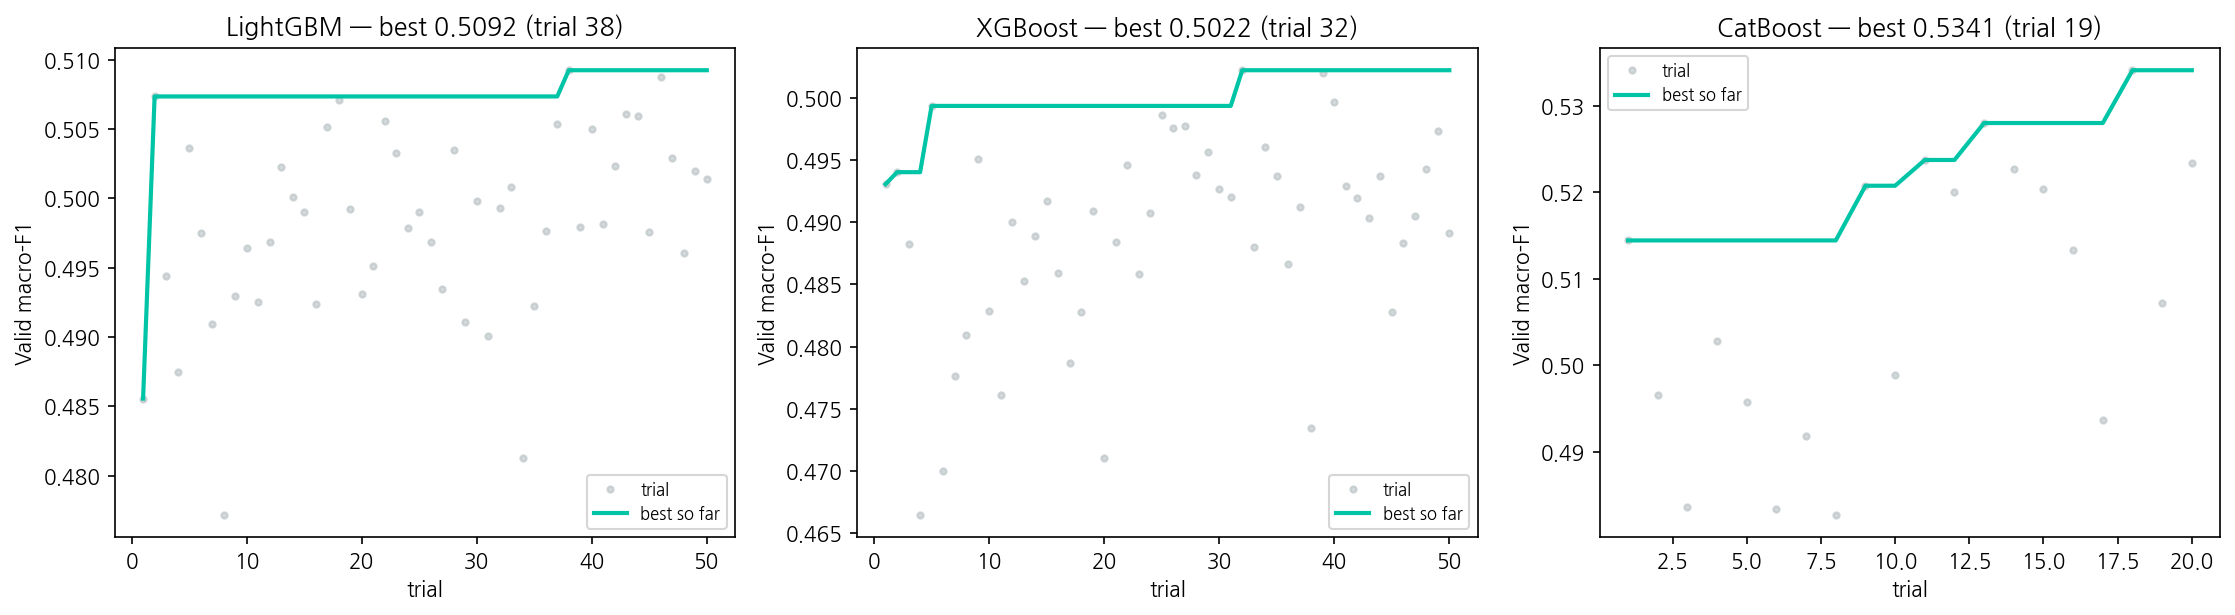

저장: models/05_optuna_best_params.json (+ optuna.db 스터디 원본)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, label) in zip(axes, [('lgbm', 'LightGBM'), ('xgb', 'XGBoost'), ('cat', 'CatBoost')]):
    st = studies[name]
    vals = [t.value for t in st.trials if t.value is not None]
    ax.plot(range(1, len(vals)+1), vals, 'o', ms=3, color=IM['중립'], alpha=0.6, label='trial')
    ax.plot(range(1, len(vals)+1), np.maximum.accumulate(vals), color=IM['민트'], lw=2, label='best so far')
    ax.set_title(f'{label} — best {st.best_value:.4f} (trial {st.best_trial.number+1})')
    ax.set_xlabel('trial'); ax.set_ylabel('Valid macro-F1'); ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, '05_01_optuna_history.png'); plt.show()

json.dump({k: {'best_value': s.best_value, 'best_params': s.best_params,
               'n_trials': len(s.trials)} for k, s in studies.items()},
          open('../models/05_optuna_best_params.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)
print('저장: models/05_optuna_best_params.json (+ optuna.db 스터디 원본)')

**해석 —** 탐색 결과(Valid macro-F1): LGBM **0.5092**(best trial 38/50), XGB **0.5022**(trial 32/50), CatBoost **0.5341**(20 trials — 사용자 축소 확정에도 3종 중 최고). CatBoost best는 depth 10 + l2_leaf_reg 13.5 + bagging_temperature 4.3의 **"깊게 만들되 강하게 규제·랜덤화"** 조합(learning_rate 0.0998, iterations 1,085) — 베이스라인의 기본 depth 6 대비 상호작용을 더 깊게 잡되 과적합을 정규화로 눌렀다. XGB는 50 trials에도 +0.0069로 개선폭 최소 — 이 데이터에서 탐색 대비 수익이 낮다. CatBoost는 trial당 비용이 커서 20으로 끊었지만 12→20 구간에서 0.5208→0.5341로 뛰어, 필요 시 추가 탐색 여지가 남아 있다(현재는 20 확정).

## 2. 튜닝 모델 재적합 → 베이스라인 대비 Valid 전 지표 비교

In [4]:
BASE = {'LightGBM': 0.4960, 'XGBoost': 0.4953, 'CatBoost': 0.5038}   # 04 베이스라인 Valid macro-F1
rows, fitted, probas = [], {}, {}
for name, label in [('lgbm', 'LightGBM'), ('xgb', 'XGBoost'), ('cat', 'CatBoost')]:
    p = dict(studies[name].best_params)
    if name == 'lgbm':
        p['subsample_freq'] = 1   # space()의 고정값 — best_params에 미포함이라 재적합 시 명시(스터디 best 재현)
    model = build_model(name, p)
    pred, proba = fit_predict_valid(name, model)
    ev = eval_all(yva, pred, proba)
    rows.append({'모델': f'{label}(Optuna)', **{k: round(v, 4) for k, v in ev.items()},
                 '베이스라인 F1(macro)': BASE[label], 'ΔF1': round(ev['F1(macro)'] - BASE[label], 4)})
    fitted[name], probas[name] = model, proba

tab = pd.DataFrame(rows).set_index('모델')
display(tab[['F1(macro)', '베이스라인 F1(macro)', 'ΔF1', 'PR-AUC(macro)', 'AP_급증', 'AP_급감',
             'F1_급증', 'F1_급감', 'recall_급증', 'recall_급감', 'BalancedAcc', 'MCC', 'LogLoss', '(참고)Acc']])
tab.to_csv('../outputs/tables/05_optuna_valid_비교.csv', encoding='utf-8-sig')

import joblib
for name, fname in [('lgbm', '05_lgbm_optuna'), ('xgb', '05_xgb_optuna'), ('cat', '05_cat_optuna')]:
    joblib.dump(fitted[name], f'../models/{fname}.pkl')
np.save('../models/05_valid_probas.npy', np.stack([probas[n] for n in ['lgbm', 'xgb', 'cat']]))
print('저장: 05_lgbm_optuna.pkl, 05_xgb_optuna.pkl, 05_cat_optuna.pkl, 05_valid_probas.npy')

,F1(macro),베이스라인 F1(macro),ΔF1,PR-AUC(macro),AP_급증,AP_급감,F1_급증,F1_급감,recall_급증,recall_급감,BalancedAcc,MCC,LogLoss,(참고)Acc
모델,,,,,,,,,,,,,,
LightGBM(Optuna),0.5092,0.4960,0.0132,0.5390,0.1660,0.5269,0.2026,0.4570,0.2385,0.3833,0.4979,0.2664,0.7081,0.7713
XGBoost(Optuna),0.5022,0.4953,0.0069,0.5310,0.1347,0.5308,0.1903,0.5081,0.3462,0.5222,0.5372,0.2631,0.6780,0.6891
CatBoost(Optuna),0.5341,0.5038,0.0303,0.5423,0.1402,0.5566,0.2055,0.5217,0.2308,0.4667,0.5248,0.3109,0.5471,0.7837


저장: 05_lgbm_optuna.pkl, 05_xgb_optuna.pkl, 05_cat_optuna.pkl, 05_valid_probas.npy


**해석 —** 재적합 통일 평가: **CatBoost(Optuna)가 Valid macro-F1 0.5341 / PR-AUC(macro) 0.5423으로 단독 선두** — 베이스라인(0.5038/0.5343) 대비 +0.0303/+0.0080. PR-AUC 분해: **AP_급감 0.5566(유병률 0.106의 ×5.3)**으로 급감 신호가 더 강해졌고, AP_급증은 0.1402(×1.8)로 여전히 최난 — 급증 AP는 오히려 **LGBM(0.1660)이 최고**라서 06 확률 평균 앙상블에서 보완될 여지가 있다. 모델 성격도 갈린다: XGB는 급증 recall 0.346의 recall형, CatBoost는 정밀형(급증 precision 우위·LogLoss 0.5471 최저·MCC 0.3109 최고) — 앙상블 다양성의 근거. LGBM 재적합이 스터디 best와 일치(0.5092)하도록 고정 파라미터(subsample_freq=1) 누락을 수정했다.

## 3. 운영 임계 탐색(참고) — 클래스 확률 가중 argmax로 macro-F1 최적 운영점·급감 recall 지향점

기본 argmax는 균형 가중 학습에도 불구하고 '유지'로 보수적으로 붙는다(04 confusion). 급증·급감 확률에 배율 w를 곱한 뒤 argmax하는 단순한 운영 규칙으로 Valid에서 운영점을 탐색한다. (Valid로 고른 운영점이므로 역시 낙관 편향 — Test 확정은 06)

대상 모델: CatBoost(Optuna)


기본 argmax(w=1,1): F1 0.5341 / 급감 R 0.467 P 0.592 / 급증 R 0.231 P 0.185
macro-F1 최적점 (w_급감=2.4, w_급증=1.0): F1 0.5483 / 급감 R 0.639 P 0.520 / 급증 R 0.215 P 0.188
급감 recall≥0.60 지향점 (w_급감=2.4, w_급증=2.0): 급감 R 0.600 P 0.532 / F1 0.5228 — 이탈 방지 개입용


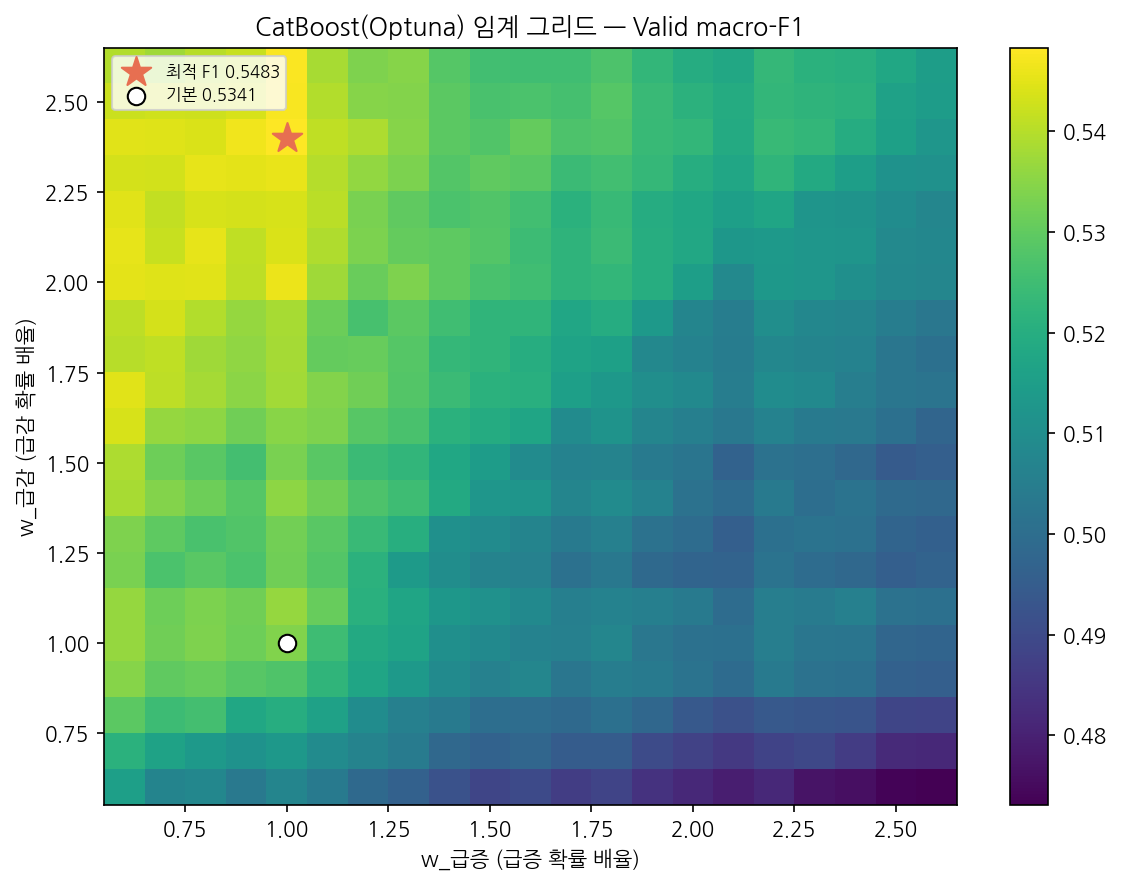

In [5]:
best_name = max(fitted, key=lambda n: f1_score(yva, np.array(CLS)[np.argmax(probas[n], axis=1)], average='macro'))
P = probas[best_name]
label_map = {'lgbm': 'LightGBM', 'xgb': 'XGBoost', 'cat': 'CatBoost'}
print(f'대상 모델: {label_map[best_name]}(Optuna)')

grid = np.arange(0.6, 2.61, 0.1)
res = []
for w_dn in grid:        # 급감 배율
    for w_up in grid:    # 급증 배율
        W = np.array([w_dn, w_up, 1.0])
        pred = np.array(CLS)[np.argmax(P * W, axis=1)]
        res.append({'w_급감': round(w_dn, 2), 'w_급증': round(w_up, 2),
                    'F1(macro)': f1_score(yva, pred, average='macro'),
                    'recall_급감': recall_score(yva, pred, labels=['급감'], average='macro'),
                    'precision_급감': precision_score(yva, pred, labels=['급감'], average='macro', zero_division=0),
                    'recall_급증': recall_score(yva, pred, labels=['급증'], average='macro'),
                    'precision_급증': precision_score(yva, pred, labels=['급증'], average='macro', zero_division=0)})
res = pd.DataFrame(res)
res.to_csv('../outputs/tables/05_임계그리드.csv', index=False, encoding='utf-8-sig')

opt = res.loc[res['F1(macro)'].idxmax()]
base_row = res[(res['w_급감'] == 1.0) & (res['w_급증'] == 1.0)].iloc[0]
print(f"기본 argmax(w=1,1): F1 {base_row['F1(macro)']:.4f} / 급감 R {base_row['recall_급감']:.3f} P {base_row['precision_급감']:.3f} / 급증 R {base_row['recall_급증']:.3f} P {base_row['precision_급증']:.3f}")
print(f"macro-F1 최적점 (w_급감={opt['w_급감']}, w_급증={opt['w_급증']}): F1 {opt['F1(macro)']:.4f} / 급감 R {opt['recall_급감']:.3f} P {opt['precision_급감']:.3f} / 급증 R {opt['recall_급증']:.3f} P {opt['precision_급증']:.3f}")

cand = res[res['recall_급감'] >= 0.60]
if len(cand):
    ops = cand.loc[cand['precision_급감'].idxmax()]
    print(f"급감 recall≥0.60 지향점 (w_급감={ops['w_급감']}, w_급증={ops['w_급증']}): 급감 R {ops['recall_급감']:.3f} P {ops['precision_급감']:.3f} / F1 {ops['F1(macro)']:.4f} — 이탈 방지 개입용")

piv = res.pivot_table(index='w_급감', columns='w_급증', values='F1(macro)')
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(piv.values, cmap='viridis', origin='lower', aspect='auto',
               extent=[grid[0]-0.05, grid[-1]+0.05, grid[0]-0.05, grid[-1]+0.05])
ax.scatter([opt['w_급증']], [opt['w_급감']], marker='*', s=220, color=IM['코랄'],
           label=f"최적 F1 {opt['F1(macro)']:.4f}")
ax.scatter([1], [1], marker='o', s=70, color='white', edgecolor='black', label=f"기본 {base_row['F1(macro)']:.4f}")
ax.set_xlabel('w_급증 (급증 확률 배율)'); ax.set_ylabel('w_급감 (급감 확률 배율)')
ax.set_title(f'{label_map[best_name]}(Optuna) 임계 그리드 — Valid macro-F1')
fig.colorbar(im, ax=ax); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); save_fig(fig, '05_02_임계그리드.png'); plt.show()

json.dump({'model': best_name, 'w_급감': float(opt['w_급감']), 'w_급증': float(opt['w_급증']),
           'valid_f1': float(opt['F1(macro)'])},
          open('../models/05_운영임계.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1)

**해석 —** CatBoost(Optuna) 확률에 **급감 배율 w=2.4**만 주면 Valid macro-F1이 **0.5341 → 0.5483(+0.0142)**으로 오른다: 급감 recall 0.467 → **0.639**(180건 중 115건 포착), precision은 0.592 → 0.520으로 완만히 하락 — 04에서 본 "유지로의 보수적 흡수"가 임계 조정으로 상당 부분 회수된다. 반면 **급증은 배율을 올려도 이득이 없다**(최적 w_급증=1.0) — 급증 확률 자체의 판별력이 낮아 임계로는 해결되지 않는 구조적 난제(AP 0.14)임을 재확인. 운영 관점 제안: 이탈 방지 개입용으로는 급감 recall≥0.60 지향점(w_급감 2.4·w_급증 2.0: R 0.600/P 0.532)도 병기. 이 운영점은 Valid로 고른 것이므로 06에서 앙상블 확정 후 **Test에 1회만 적용해 유효성을 검증**한다. `models/05_운영임계.json` 저장.

## 결론 — 05(1/2) 산출 요약

① Optuna(Valid 직접 최적화, 사용자 확정): **CatBoost 0.5038 → 0.5341(+0.0303)**, LGBM → 0.5092(+0.0132), XGB → 0.5022(+0.0069). ② 운영 임계(w_급감 2.4) 추가 시 **0.5483** — 베이스라인 대비 누적 **+0.0445**. ③ 급증(AP 0.14~0.17)은 튜닝·임계 모두로 해결되지 않는 최난 클래스로 확정 — 05(2/2) DL과 06 앙상블에서 보완 시도. ④ 모든 수치는 Valid 기준 선택 편향 포함 — **공정한 최종 성능은 06 Holdout-Test 1회 보고**. 산출물: `05_lgbm/xgb/cat_optuna.pkl`, `05_optuna_best_params.json`, `05_valid_probas.npy`, `05_운영임계.json`, 그림 2장, 표 2개.

**다음(05 2/2):** DL 후보 비교표 — (a) 다변량 시퀀스 LSTM/GRU(lookback별 샘플 감소 수치) (b) 1D-CNN (c) 집계 피처 MLP — 를 제시하고 **사용자 승인 후** 구현(§10·§15).